--2026-04-06 23:45:44--  http://www.gutenberg.org/cache/epub/2000/pg2000.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.gutenberg.org/cache/epub/2000/pg2000.txt [following]
--2026-04-06 23:45:44--  https://www.gutenberg.org/cache/epub/2000/pg2000.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2225806 (2.1M) [text/plain]
Saving to: ‘pg2000.txt’

pg2000.txt          100%[===================>]   2.12M  --.-KB/s    in 0.1s    

2026-04-06 23:45:45 (22.1 MB/s) - ‘pg2000.txt’ saved [2225806/2225806]



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


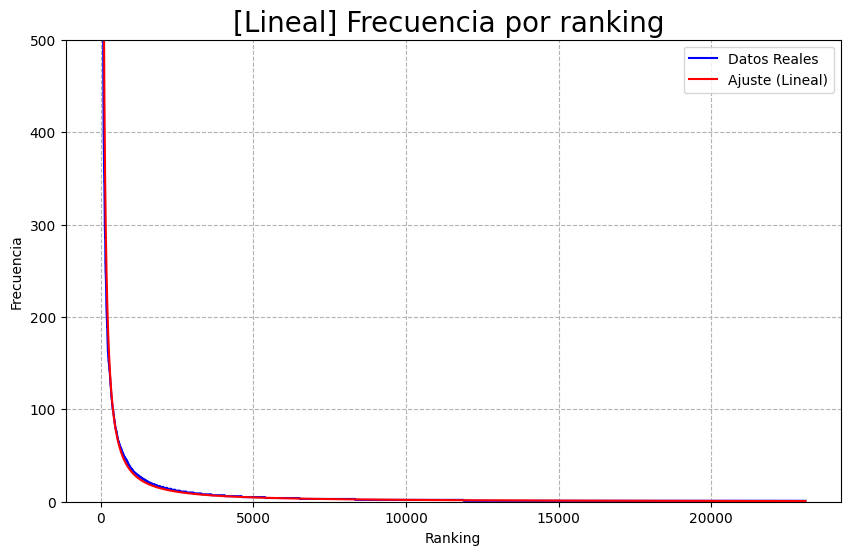

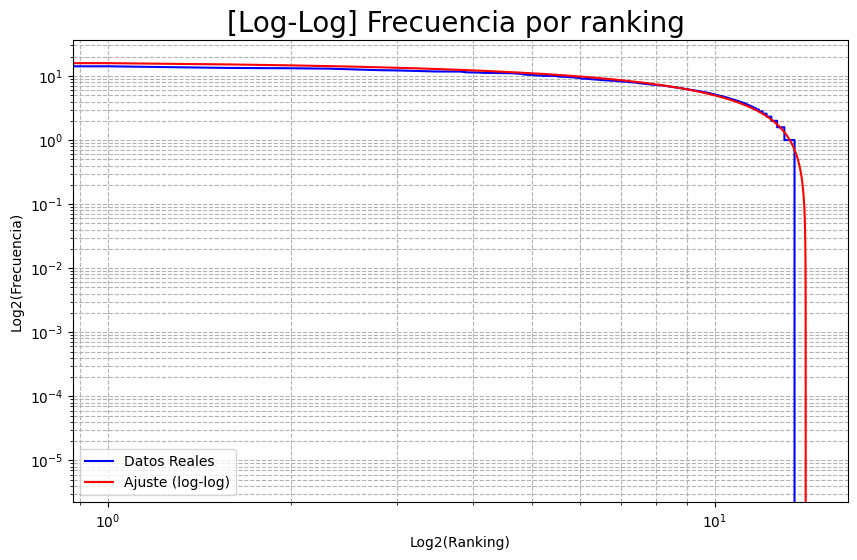

In [15]:
import os
import sys
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# VARIABLES GLOBALES
tokens = []       # tokens totales
terms = []        # terminos totales
coll_freq = {}    # colection frecuency de cada termino
max_size=30
min_size=2

# PROCESOS
def translate(string):
    """
    Convierte caracteres acentuados a su forma no acentuada.
    """
    return (
        unicodedata.normalize("NFD", string)
        .encode("ascii", "ignore")
        .decode("ascii")
    )

def tokenize(text):
    """
    Tokeniza el texto extrayendo solo palabras comunes (letras).
    """
    text = text.lower()
    text = translate(text)
    word_re = re.compile(r"[a-z]+(?:[-'][a-z]+)*")
    return word_re.findall(text)

# Elimina palabras vacias; elimina duplicados; cuenta frecuencias de cada termino
def delete_stopwords(tokens_doc, stopwords,delete_sw):

    for token in tokens_doc:
        if len(token)>= min_size and len(token)<=max_size:
            if delete_sw==True:
                if token not in stopwords: # elimina palabras vacias
                    if token not in terms:
                        terms.append(token)
                        coll_freq[token] = 1
                    else:             # elimina duplicados
                        coll_freq[token]+=1
            else: #si no se tienen que eliminar palabras vacias, se pasan todas.
                if token not in terms:
                    terms.append(token)
                    coll_freq[token] = 1
                else:             # elimina duplicados
                    coll_freq[token]+=1
    return terms

# MAIN ------------------------------------------------------------------------------------------------
!rm pg2000.txt
!wget http://www.gutenberg.org/cache/epub/2000/pg2000.txt
file1 = open('pg2000.txt', "r")                           # Lee el archivo
nltk.download('stopwords')
stop_words = stopwords.words("spanish")                   # Palabras vacias en español
tokens_doc = tokenize(file1.read())                      # Obtiene tokens (no filtra repetidos)
delete_sw = False
terms = delete_stopwords(tokens_doc,stop_words,delete_sw) # filtra los terminos y sus frecuencias
list_freq = []
for k in coll_freq.keys():                                # terminos a una lista
    list_freq.append(coll_freq[k])

list_freq = sorted(list_freq, key=None,reverse=True)      # ordena frecuencias de mayor a menor

y = list_freq                       # frecuencias
x = list(range(1,len(list_freq)+1)) # ranking

# Ajuste de datos
xlog = np.log2(x)
ylog = np.log2(y)
ajuste = np.polyfit(xlog,ylog,1)
rectaAjusteEc = np.poly1d(ajuste)
y_pred = rectaAjusteEc(xlog)
r2 = r2_score(y,y_pred)

# transforma a escala lineal para graph 1
y_pred_linear = 2**y_pred

# Grafico lineal
plt.figure(figsize=(10, 6))
plt.xscale('linear')
plt.plot(x,y, color='blue', label = 'Datos Reales')
plt.plot(x,y_pred_linear, color='red' , label='Ajuste (Lineal)') # Added linear fit
plt.title('[Lineal] Frecuencia por ranking ', size = 20)
plt.xlabel('Ranking')
plt.ylabel('Frecuencia')
plt.legend(loc='best')
plt.grid(True, which='both', ls='--', c='0.7')
plt.ylim(0, 500) # Added to adjust y-axis limit
plt.show()

# Grafico log-log
plt.figure(figsize=(10, 6))
plt.plot(xlog, ylog, color='blue', label='Datos Reales') # Plot log-transformed real data
plt.xscale('log')
plt.yscale('log')
plt.plot(xlog, y_pred, color='red', label='Ajuste (log-log)') # Plot log-transformed fit
plt.title('[Log-Log] Frecuencia por ranking ', size = 20)
plt.xlabel('Log2(Ranking)')
plt.ylabel('Log2(Frecuencia)')
plt.legend(loc='best')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()